In [256]:
from utils import *
import os
seed = 42

def plot_ipcw_weights(
    weights,
    label=r"$IPC w_i$",
    savepath=None
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    weights = np.asarray(weights)

    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(6, 2.5))

    # Stripplot
    sns.stripplot(
        x=weights,
        jitter=0.25,
        alpha=0.5,
        size=2,
        color="teal",
        ax=ax
    )

    ax.set_ylabel("")
    ax.set_xlabel(label)

    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300)
        plt.show()

In [ ]:
# simulation parameters
 
n_sim = 1000
n = int(1000.5/0.7)
B_RF = int(1000 )
n_covariates = 4

# data generation parameters and RF parameters
X_pred_point = pd.DataFrame({'X_1': [0], 'X_2': [1], 'X_3': [80], 'X_4': [40]})
data_generation_parameter_1 =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': n,
                                    'scale_weibull_base':   22_080       , 
                                    'rate_censoring':       0.00321    , 
                                    'tau': 37, 
                                    'X_pred_point': X_pred_point}  

data_generation_parameter_3 =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': n,
                                    'scale_weibull_base':  18_900        , 
                                    'rate_censoring':       0.01125   , 
                                    'tau': 37, 
                                    'X_pred_point': X_pred_point }

data_generation_parameter_5 =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': n,
                                    'scale_weibull_base':  15120        , 
                                    'rate_censoring':       0.023293   , 
                                    'tau': 37, 
                                    'X_pred_point': X_pred_point }

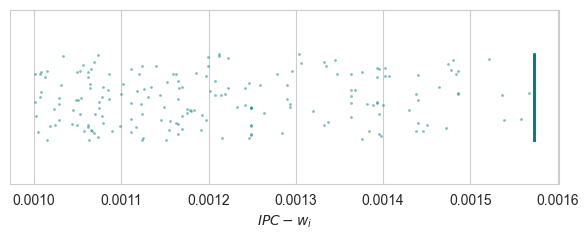

In [258]:
data = create_weibull_data(params=data_generation_parameter_3, random_state=seed)
df_train, df_test = stratified_split(data=data, random_state=seed, test_size=0.3)
df_train = create_data_with_ipc_weights(data=df_train, params=data_generation_parameter_3)

df_train["weights_ipcw"].value_counts()

os.makedirs("weight_plots", exist_ok=True)


values = df_train.loc[df_train["weights_ipcw"] > 0, "weights_ipcw"]

plot_ipcw_weights(
    weights=values,
    label=r"$IPC - w_i$",
    savepath="weight_plots/ipcw_weights_30.jpeg"
)